# Robust Portfolio Optimization

**Docker image**: `ml4t`

This notebook explores portfolio optimization techniques beyond classical MVO,
including risk parity, minimum variance, minimum CDaR, and HRP
using the Riskfolio-Lib library.

**Learning Objectives**:
- Implement risk parity for equal risk contribution across assets
- Compare robust optimization approaches that handle estimation error
- Evaluate diversification metrics (effective N, risk contribution)
- Understand tail-risk optimization with CDaR

**Book Reference**: Chapter 17, §17.5 (Mean-Variance Optimization and the Markowitz Curse)

**Prerequisites**: `02_mean_variance_optimization`, ETF price data

## Setup

In [1]:
"""Compare Riskfolio-Lib allocators with Ledoit-Wolf shrinkage, risk contributions, rolling Sharpe, and an execution bridge."""

import warnings

warnings.filterwarnings("ignore")

import cvxpy.reductions.matrix_stuffing as cvxpy_matrix_stuffing
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
from cvxpy.problems.problem import Problem as _CvxpyProblem

missing_cvxpy_symbols = [
    name
    for name in ("extract_lower_bounds", "extract_upper_bounds")
    if not hasattr(cvxpy_matrix_stuffing, name)
]
if not hasattr(_CvxpyProblem, "_supports_cpp"):
    missing_cvxpy_symbols.append("Problem._supports_cpp")
if missing_cvxpy_symbols:
    raise RuntimeError(
        "Incompatible cvxpy runtime for the Riskfolio-Lib robust-optimization notebook. "
        "Install the supported cvxpy stack instead of patching site-packages at runtime. "
        f"Missing symbols: {missing_cvxpy_symbols}"
    )

import riskfolio as rp
from ml4t.backtest import (
    BacktestConfig,
    CommissionType,
    DataFeed,
    Engine,
    ExecutionMode,
    Strategy,
)
from ml4t.backtest.config import SlippageType
from ml4t.backtest.execution.rebalancer import RebalanceConfig, TargetWeightExecutor

# Evaluation
from ml4t.diagnostic.evaluation import (
    PortfolioAnalysis,
)
from plotly.subplots import make_subplots

from data import load_etfs
from utils.reproducibility import set_global_seeds

In [2]:
# Production defaults — Papermill overrides for CI testing
SEED = 42

In [3]:
set_global_seeds(SEED)

## 1. Data Acquisition

We'll use a diversified portfolio of ETFs spanning multiple asset classes.

In [4]:
# Multi-asset ETF universe
ETF_UNIVERSE = {
    # US Equity
    "SPY": "S&P 500",
    "QQQ": "NASDAQ 100",
    "IWM": "Russell 2000",
    # International Equity
    "EFA": "EAFE (Developed)",
    "EEM": "Emerging Markets",
    # Fixed Income
    "AGG": "US Aggregate Bond",
    "TLT": "Long Treasury",
    "HYG": "High Yield Corporate",
    # Alternatives
    "GLD": "Gold",
    "VNQ": "Real Estate",
    "DBC": "Commodities",
}

SYMBOLS = list(ETF_UNIVERSE.keys())
START_DATE = "2015-01-01"
END_DATE = "2024-01-01"

In [5]:
# Load data from canonical ETFs
print("Loading ETF data...")
etf_data = load_etfs()
etf_filtered = etf_data.filter(
    (pl.col("symbol").is_in(SYMBOLS))
    & (pl.col("timestamp") >= pl.lit(START_DATE).str.to_datetime())
    & (pl.col("timestamp") <= pl.lit(END_DATE).str.to_datetime())
)

close_prices = (
    etf_filtered.select(["timestamp", "symbol", "close"])
    .pivot(on="symbol", index="timestamp", values="close")
    .sort("timestamp")
    .to_pandas()
    .set_index("timestamp")
    .ffill()
    .dropna()
)
print(f"Loaded {len(close_prices):,} days for {close_prices.shape[1]} ETFs")

Loading ETF data...
Loaded 2,264 days for 11 ETFs


In [6]:
# Compute returns
returns = close_prices.pct_change().dropna()
print(f"Return series: {len(returns):,} observations")

# Summary statistics
summary = returns.describe().T
summary["annual_return"] = returns.mean() * 252
summary["annual_vol"] = returns.std() * np.sqrt(252)
summary["sharpe"] = summary["annual_return"] / summary["annual_vol"]
print("\nETF Summary Statistics:")
print(summary[["annual_return", "annual_vol", "sharpe"]].round(4))

Return series: 2,263 observations

ETF Summary Statistics:
     annual_return  annual_vol  sharpe
AGG         0.0142      0.0529  0.2687
DBC         0.0470      0.1822  0.2581
EEM         0.0486      0.2118  0.2293
EFA         0.0689      0.1771  0.3891
GLD         0.0673      0.1402  0.4803
HYG         0.0394      0.0888  0.4434
IWM         0.0977      0.2270  0.4305
QQQ         0.1865      0.2221  0.8399
SPY         0.1279      0.1810  0.7065
TLT         0.0073      0.1544  0.0474
VNQ         0.0710      0.2129  0.3334


This cross-asset mix is deliberate: robust allocators are most useful when the
universe contains assets with genuinely different risk and correlation profiles.

## 2. Correlation Analysis

Understanding correlations is essential for portfolio construction.

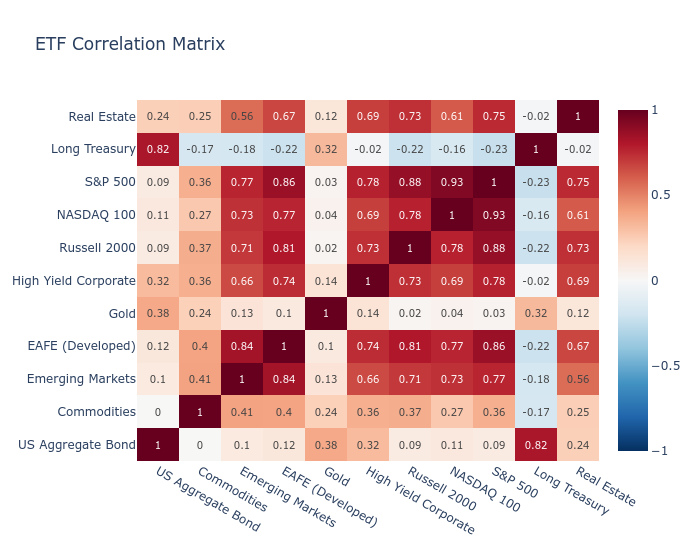

In [7]:
# Correlation matrix
corr_matrix = returns.corr()

# Heatmap
fig = go.Figure(
    data=go.Heatmap(
        z=corr_matrix.values,
        x=[ETF_UNIVERSE[s] for s in corr_matrix.columns],
        y=[ETF_UNIVERSE[s] for s in corr_matrix.index],
        colorscale="RdBu_r",
        zmid=0,
        text=np.round(corr_matrix.values, 2),
        texttemplate="%{text}",
        textfont={"size": 10},
    )
)

fig.update_layout(
    title="ETF Correlation Matrix",
    height=550,
    width=700,
)
fig.show()

## 3. Portfolio Optimization Setup

We'll use riskfolio-lib's `Portfolio` class for all optimizations.

In [8]:
# Create portfolio object
port = rp.Portfolio(returns=returns)

# Estimate expected returns and covariance
# Using historical mean and Ledoit-Wolf shrinkage for covariance
port.assets_stats(method_mu="hist", method_cov="ledoit")

print("Expected Returns (Annual):")
print((port.mu * 252).round(4))
print("\nCovariance estimated with Ledoit-Wolf shrinkage")

Expected Returns (Annual):
      AGG    DBC     EEM     EFA     GLD     HYG     IWM     QQQ     SPY  \
0  0.0142  0.047  0.0486  0.0689  0.0673  0.0394  0.0977  0.1865  0.1279   

      TLT    VNQ  
0  0.0073  0.071  

Covariance estimated with Ledoit-Wolf shrinkage


## 4. Optimization Methods Comparison

We compare six portfolio optimization approaches. The risk parity objective minimizes
the dispersion of risk contributions:

$$\min_w \sum_{i=1}^{N} \left( w_i \cdot (\Sigma w)_i - \frac{w^\top \Sigma w}{N} \right)^2$$

where $(\Sigma w)_i$ is asset $i$'s marginal risk contribution. At optimality, each asset
contributes equally to portfolio variance.

1. **Mean-Variance (Max Sharpe)**
2. **Minimum Variance**
3. **Risk Parity (ERC)**
4. **Hierarchical Risk Parity (HRP)**
5. **Min CDaR** (tail-risk optimization)
6. **Equal Weight (Benchmark)**

In [9]:
OPTIMIZATION_SPECS = {
    "max_sharpe": {
        "name": "Max Sharpe (MVO)",
        "call": lambda port: port.optimization(
            model="Classic", rm="MV", obj="Sharpe", rf=0, hist=True
        ),
    },
    "min_variance": {
        "name": "Minimum Variance",
        "call": lambda port: port.optimization(
            model="Classic", rm="MV", obj="MinRisk", rf=0, hist=True
        ),
    },
    "risk_parity": {
        "name": "Risk Parity",
        "call": lambda port: port.rp_optimization(model="Classic", rm="MV", rf=0, hist=True),
    },
    "min_cdar": {
        "name": "Min CDaR",
        "call": lambda port: port.optimization(
            model="Classic", rm="CDaR", obj="MinRisk", rf=0, hist=True
        ),
    },
}

Map each optimization label to the Riskfolio-Lib call so the portfolio function can
focus on orchestration rather than on a long method-specific branch ladder.

In [10]:
def optimize_portfolio(method: str) -> dict:
    """Optimize one of the robust allocation methods."""
    if method == "equal_weight":
        weights = pd.DataFrame({"weights": [1 / len(SYMBOLS)] * len(SYMBOLS)}, index=SYMBOLS)
        return {"name": "Equal Weight", "weights": weights["weights"].to_dict(), "method": method}

    if method == "hrp":
        w = rp.HCPortfolio(returns=returns).optimization(
            model="HRP",
            codependence="pearson",
            rm="MV",
            rf=0,
            linkage="ward",
            max_k=10,
            leaf_order=True,
            method_cov="ledoit",
        )
        return {
            "name": "HRP",
            "weights": w["weights"].to_dict() if w is not None else None,
            "method": method,
        }

    if method not in OPTIMIZATION_SPECS:
        raise ValueError(f"Unknown method: {method}")

    port = rp.Portfolio(returns=returns)
    port.assets_stats(method_mu="hist", method_cov="ledoit")
    spec = OPTIMIZATION_SPECS[method]
    w = spec["call"](port)

    return {
        "name": spec["name"],
        "weights": w["weights"].to_dict() if w is not None else None,
        "method": method,
    }

In [11]:
# Run all optimizations
METHODS = [
    "max_sharpe",
    "min_variance",
    "risk_parity",
    "hrp",
    "min_cdar",
    "equal_weight",
]

results = {}
for method in METHODS:
    result = optimize_portfolio(method)
    if result["weights"] is None:
        raise RuntimeError(f"{method} optimization returned no weights.")
    results[method] = result
    print(f"  {result['name']}: Optimized successfully")

  Max Sharpe (MVO): Optimized successfully
  Minimum Variance: Optimized successfully
  Risk Parity: Optimized successfully
  HRP: Optimized successfully


  Min CDaR: Optimized successfully
  Equal Weight: Optimized successfully


## 5. Weight Comparison

In [12]:
# Create weight comparison dataframe
weight_df = pd.DataFrame({results[m]["name"]: results[m]["weights"] for m in results.keys()})
weight_df.index = [ETF_UNIVERSE.get(s, s) for s in weight_df.index]

# Display
weight_df.round(4)

,Max Sharpe (MVO),Minimum Variance,Risk Parity,HRP,Min CDaR,Equal Weight
US Aggregate Bond,0.0000,0.7960,0.2338,0.5054,0.5122,0.0909
Commodities,0.0000,0.0550,0.0854,0.0366,0.1216,0.0909
Emerging Markets,0.0000,0.0000,0.0497,0.0272,0.0000,0.0909
EAFE (Developed),0.0000,0.0000,0.0565,0.0541,0.0000,0.0909
Gold,0.4345,0.0000,0.1154,0.1191,0.0600,0.0909
High Yield Corporate,0.0000,0.1491,0.1071,0.1279,0.3062,0.0909
Russell 2000,0.0000,0.0000,0.0461,0.0090,0.0000,0.0909
NASDAQ 100,0.5291,0.0000,0.0478,0.0174,0.0000,0.0909
S&P 500,0.0000,0.0000,0.0550,0.0141,0.0000,0.0909
Long Treasury,0.0364,0.0000,0.1543,0.0661,0.0000,0.0909


**Interpretation**: The weight table shows which methods diversify by construction
and which diversify only if the estimated return inputs cooperate. That distinction
matters more out of sample than small differences in in-sample Sharpe.

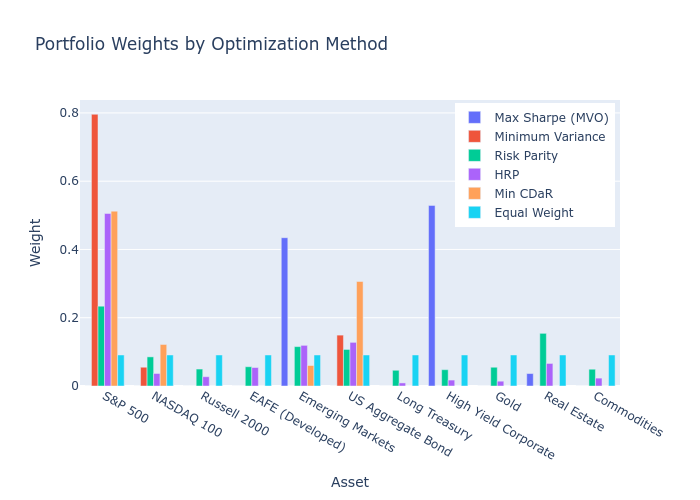

In [13]:
# Stacked bar chart
fig = go.Figure()

for method in results.keys():
    weights = list(results[method]["weights"].values())
    fig.add_trace(
        go.Bar(
            name=results[method]["name"],
            x=[ETF_UNIVERSE[s] for s in SYMBOLS],
            y=weights,
        )
    )

fig.update_layout(
    title="Portfolio Weights by Optimization Method",
    xaxis_title="Asset",
    yaxis_title="Weight",
    barmode="group",
    height=500,
    legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99),
)
fig.show()

## 6. Backtest Each Portfolio

In [14]:
def backtest_portfolio(weights: dict, returns: pd.DataFrame) -> pd.Series:
    """Compute portfolio returns from static weights."""
    weight_series = pd.Series(weights)
    available = [c for c in weight_series.index if c in returns.columns]
    if not available:
        return pd.Series(0.0, index=returns.index)
    weight_series = weight_series.loc[available]
    gross = float(weight_series.abs().sum())
    if gross > 0:
        weight_series = weight_series / gross
    aligned_returns = returns[available]
    portfolio_returns = (aligned_returns * weight_series).sum(axis=1)
    return portfolio_returns


# Backtest all portfolios
portfolio_returns = {}
for method, result in results.items():
    port_ret = backtest_portfolio(result["weights"], returns)
    portfolio_returns[result["name"]] = port_ret

# Convert to DataFrame
returns_df = pd.DataFrame(portfolio_returns)
print(f"Backtest period: {returns_df.index[0].date()} to {returns_df.index[-1].date()}")

Backtest period: 2015-01-05 to 2023-12-29


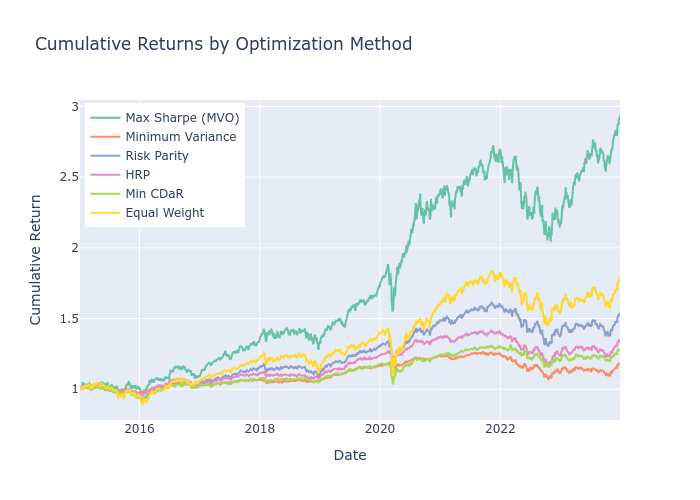

In [15]:
# Compute cumulative returns
cumulative = (1 + returns_df).cumprod()

# Plot
fig = go.Figure()

colors = px.colors.qualitative.Set2
for i, col in enumerate(cumulative.columns):
    fig.add_trace(
        go.Scatter(
            x=cumulative.index,
            y=cumulative[col],
            name=col,
            line=dict(color=colors[i % len(colors)], width=2),
        )
    )

fig.update_layout(
    title="Cumulative Returns by Optimization Method",
    xaxis_title="Date",
    yaxis_title="Cumulative Return",
    height=500,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
)
fig.show()

## 7. Performance Comparison

In [16]:
# Compute metrics for each portfolio
metrics_data = []

for name, ret in portfolio_returns.items():
    analysis = PortfolioAnalysis(
        returns=ret.values,
        periods_per_year=252,
    )
    metrics = analysis.compute_summary_stats()

    metrics_data.append(
        {
            "Portfolio": name,
            "Annual Return": f"{metrics.annual_return * 100:.2f}%",
            "Annual Vol": f"{metrics.annual_volatility * 100:.2f}%",
            "Sharpe": f"{metrics.sharpe_ratio:.3f}",
            "Sortino": f"{metrics.sortino_ratio:.3f}",
            "Max DD": f"{metrics.max_drawdown * 100:.2f}%",
            "Calmar": f"{metrics.calmar_ratio:.3f}",
        }
    )

metrics_df = pd.DataFrame(metrics_data)
metrics_df

,Portfolio,Annual Return,Annual Vol,Sharpe,Sortino,Max DD,Calmar
0,Max Sharpe (MVO),12.65%,13.46%,0.952,0.904,-24.85%,0.509
1,Minimum Variance,1.87%,5.01%,0.395,0.364,-15.10%,0.124
2,Risk Parity,4.84%,8.26%,0.614,0.571,-19.63%,0.247
3,HRP,3.36%,6.28%,0.558,0.525,-17.78%,0.189
4,Min CDaR,2.78%,5.72%,0.509,0.480,-12.73%,0.219
5,Equal Weight,6.58%,11.62%,0.607,0.564,-23.27%,0.283


**Interpretation**: Risk parity and minimum variance shift the trade-off toward
shallower drawdowns and lower volatility, generally at the cost of total return
in this sample. Equal weight is the comparison hurdle: a more complex optimizer
must clear it after accounting for covariance estimation error and trading costs.

Execution-aware bridge: run one robust allocator through `ml4t-backtest`. The
strategy submits one target-weight basket so the engine can add timing and costs.

In [17]:
class StaticWeightStrategy(Strategy):
    def __init__(self, target_weights: dict[str, float], allow_short: bool):
        self.target_weights = target_weights
        self.executor = TargetWeightExecutor(
            config=RebalanceConfig(
                min_trade_value=100.0,
                min_weight_change=0.001,
                allow_fractional=True,
                allow_short=allow_short,
            )
        )
        self._submitted = False

    def on_data(self, timestamp, data, context, broker):
        if self._submitted:
            return
        targets = {asset: weight for asset, weight in self.target_weights.items() if asset in data}
        if targets:
            self.executor.execute(targets, data, broker)
            self._submitted = True

In [18]:
# Prepare the chosen robust portfolio for the engine run.
weights_by_name = {
    payload["name"]: {asset: float(weight) for asset, weight in payload["weights"].items()}
    for payload in results.values()
}
bridge_name = "Risk Parity" if "Risk Parity" in weights_by_name else next(iter(weights_by_name))
engine_target_weights = weights_by_name[bridge_name]
allow_short_engine = any(weight < 0 for weight in engine_target_weights.values())

prices_panel = pl.from_pandas(close_prices.reset_index())
ts_col = prices_panel.columns[0]
if ts_col != "timestamp":
    prices_panel = prices_panel.rename({ts_col: "timestamp"})
prices_long = (
    prices_panel.unpivot(index="timestamp", variable_name="symbol", value_name="close")
    .with_columns(
        [
            pl.col("timestamp").cast(pl.Datetime("us")),
            pl.col("close").alias("open"),
            pl.col("close").alias("high"),
            pl.col("close").alias("low"),
            pl.lit(1_000_000).alias("volume"),
        ]
    )
    .sort(["timestamp", "symbol"])
)

In [19]:
# Run the engine and collect an execution-aware return series.
engine = Engine(
    feed=DataFeed(prices_df=prices_long),
    strategy=StaticWeightStrategy(engine_target_weights, allow_short=allow_short_engine),
    config=BacktestConfig(
        initial_cash=100_000.0,
        execution_mode=ExecutionMode.NEXT_BAR,
        commission_type=CommissionType.PERCENTAGE,
        commission_rate=0.0005,
        slippage_type=SlippageType.PERCENTAGE,
        slippage_rate=0.0005,
        allow_short_selling=allow_short_engine,
    ),
)

engine_daily = (
    engine.run()
    .to_daily_pnl()
    .select(
        pl.col("date").cast(pl.Datetime("us")).alias("date"),
        pl.col("return_pct").alias("engine_return"),
    )
)

vectorized_daily = pl.DataFrame(
    {
        "date": pl.Series(returns_df.index.to_list()).cast(pl.Datetime("us")),
        "vectorized_return": portfolio_returns[bridge_name].to_numpy(),
    }
)

In [20]:
# Compare frictionless and engine-based performance on the same dates.
bridge = (
    vectorized_daily.join(engine_daily, on="date", how="inner")
    .drop_nulls(["vectorized_return", "engine_return"])
    .sort("date")
)

vec_stats = PortfolioAnalysis(returns=bridge["vectorized_return"], periods_per_year=252)
eng_stats = PortfolioAnalysis(returns=bridge["engine_return"], periods_per_year=252)
vec_summary = vec_stats.compute_summary_stats()
eng_summary = eng_stats.compute_summary_stats()

print(f"\nExecution bridge ({bridge_name}):")
print(
    f"  Vectorized Sharpe={vec_summary.sharpe_ratio:.3f}, "
    f"Engine Sharpe={eng_summary.sharpe_ratio:.3f}"
)
print(
    f"  Vectorized MaxDD={vec_summary.max_drawdown:.2%}, "
    f"Engine MaxDD={eng_summary.max_drawdown:.2%}"
)


Execution bridge (Risk Parity):
  Vectorized Sharpe=0.614, Engine Sharpe=0.592
  Vectorized MaxDD=-19.63%, Engine MaxDD=-21.11%


**Interpretation**: Robust optimizers should remain competitive after modest costs.
If the bridge meaningfully erodes the ranking, the apparent advantage is coming from
fragile static weights rather than from a truly more robust allocation rule.

In [21]:
# Build the risk-return inputs before plotting the frontier-style comparison.
risk_return_data = []
for name, ret in portfolio_returns.items():
    ret_arr = ret.to_numpy(dtype=float)
    ann_ret = float(np.mean(ret_arr) * 252)
    ann_vol = float(np.std(ret_arr, ddof=1) * np.sqrt(252)) if len(ret_arr) > 1 else 0.0
    risk_return_data.append(
        {
            "name": name,
            "return": ann_ret * 100,
            "volatility": ann_vol * 100,
        }
    )

rr_df = pd.DataFrame(risk_return_data)

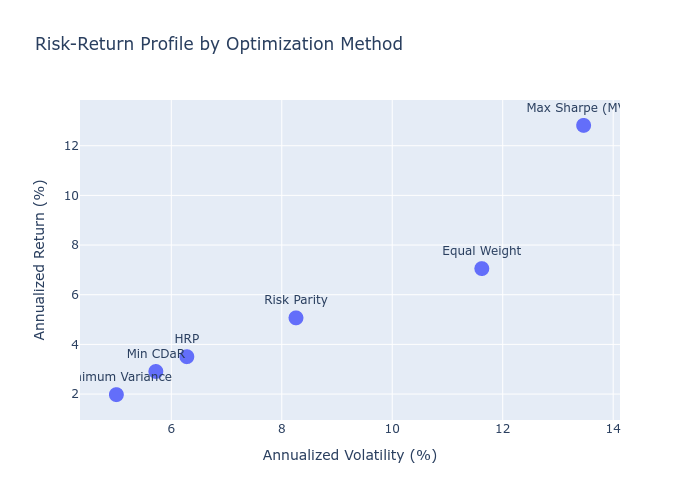

In [22]:
# Risk-Return scatter plot
fig = px.scatter(
    rr_df,
    x="volatility",
    y="return",
    text="name",
    title="Risk-Return Profile by Optimization Method",
)
fig.update_traces(textposition="top center", marker=dict(size=15))
fig.update_layout(
    xaxis_title="Annualized Volatility (%)",
    yaxis_title="Annualized Return (%)",
    height=500,
)

fig.show()

**Interpretation**: Risk parity and minimum variance typically cluster near the top of the
risk-adjusted rankings without requiring expected return estimates. Max Sharpe may win on
Sharpe ratio but concentrates in few assets, creating fragility. The Min CDaR portfolio
explicitly targets drawdown reduction, often at the cost of lower absolute returns.
Equal weight clears the comparison threshold on Sharpe in this sample, which is the
point of comparison for any optimization-based approach to demonstrate net value.

## 8. Drawdown Comparison

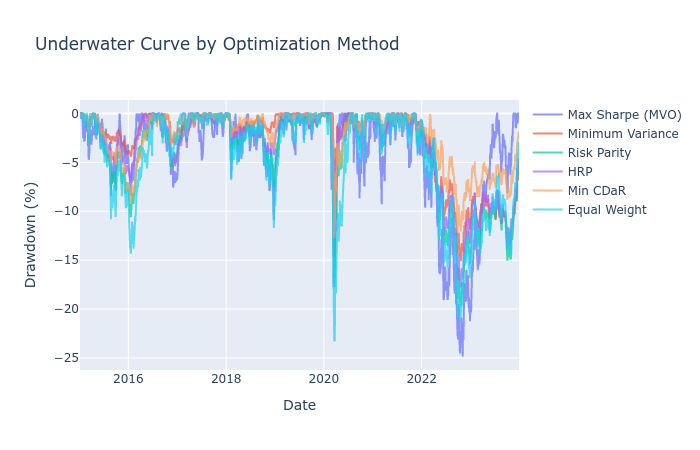

In [23]:
# Compute drawdowns
def compute_drawdown(returns: pd.Series) -> pd.Series:
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.expanding().max()
    return (cumulative - running_max) / running_max


drawdowns = pd.DataFrame({name: compute_drawdown(ret) for name, ret in portfolio_returns.items()})

# Plot
fig = go.Figure()

for col in drawdowns.columns:
    fig.add_trace(go.Scatter(x=drawdowns.index, y=drawdowns[col] * 100, name=col, opacity=0.7))

fig.update_layout(
    title="Underwater Curve by Optimization Method",
    xaxis_title="Date",
    yaxis_title="Drawdown (%)",
    height=450,
)
fig.show()

**Interpretation**: Drawdown plots show separation between portfolios that the
return summary compresses. Min-CDaR and risk-parity variants are evaluated by the
trade-off between total return given up and reduction in the depth or duration of
the worst drawdowns on this sample.

## 9. Risk Contribution Analysis

For risk parity, we verify that risk contributions are equalized.

In [24]:
def compute_risk_contribution(weights: dict, returns: pd.DataFrame) -> pd.Series:
    """Compute risk contribution for each asset."""
    w = pd.Series(weights, dtype=float)
    available = [c for c in w.index if c in returns.columns]
    if not available:
        return pd.Series(dtype=float)
    w = w.loc[available]
    gross = float(w.abs().sum())
    if gross > 0:
        w = w / gross
    cov = returns[available].cov() * 252  # Annualized covariance

    # Portfolio variance
    port_var = float(w @ cov @ w)
    if port_var <= 0:
        return pd.Series(0.0, index=w.index)

    # Marginal risk contribution
    marginal = cov @ w

    # Risk contribution
    rc = w * marginal / np.sqrt(port_var)

    # Percentage contribution
    rc_sum = float(rc.sum())
    rc_pct = rc / rc_sum if rc_sum != 0 else rc

    return rc_pct

In [25]:
# Compare risk contributions
rc_methods = ["max_sharpe", "risk_parity", "min_variance"]
rc_table = pd.DataFrame(
    {
        results[m]["name"]: compute_risk_contribution(results[m]["weights"], returns) * 100
        for m in rc_methods
        if m in results
    }
)
rc_table.index = [ETF_UNIVERSE.get(s, s) for s in rc_table.index]
rc_table.round(2)

,Max Sharpe (MVO),Risk Parity,Minimum Variance
US Aggregate Bond,0.00,8.86,78.02
Commodities,0.00,9.11,5.98
Emerging Markets,0.00,9.14,0.00
EAFE (Developed),0.00,9.13,0.00
Gold,22.65,9.08,0.00
High Yield Corporate,0.00,9.09,16.00
Russell 2000,0.00,9.14,0.00
NASDAQ 100,77.14,9.14,0.00
S&P 500,0.00,9.14,0.00
Long Treasury,0.21,9.03,0.00


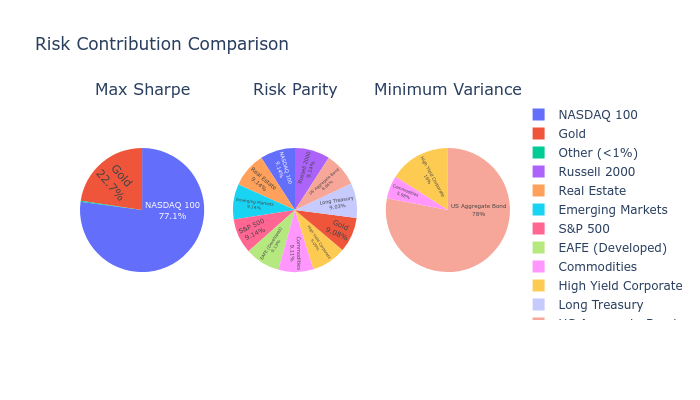

In [26]:
# Visualize risk contributions
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=["Max Sharpe", "Risk Parity", "Minimum Variance"],
    specs=[[{"type": "pie"}] * 3],
)

for i, method in enumerate(["max_sharpe", "risk_parity", "min_variance"]):
    if method in results:
        rc = compute_risk_contribution(results[method]["weights"], returns)
        # Group slices below 1% into "Other" so per-slice percent labels stay readable
        _labels = [ETF_UNIVERSE.get(a, a) for a in rc.index]
        _values = rc.values
        _total = _values.sum() if _values.sum() > 0 else 1.0
        _shares = _values / _total
        _keep = _shares >= 0.01
        _grouped_labels = [lbl for lbl, k in zip(_labels, _keep) if k] + (
            ["Other (<1%)"] if (~_keep).any() else []
        )
        _grouped_values = list(_values[_keep]) + (
            [float(_values[~_keep].sum())] if (~_keep).any() else []
        )
        fig.add_trace(
            go.Pie(
                labels=_grouped_labels,
                values=_grouped_values,
                name=results[method]["name"],
                textinfo="label+percent",
                textposition="inside",
                insidetextorientation="radial",
            ),
            row=1,
            col=i + 1,
        )

fig.update_layout(
    title="Risk Contribution Comparison",
    height=400,
)
fig.show()

**Interpretation**: Equal capital weights are not equal risk weights. The pie charts
show whether one or two volatile assets dominate portfolio behavior even when the
allocation looks diversified in dollar terms.

## 10. Rolling Performance

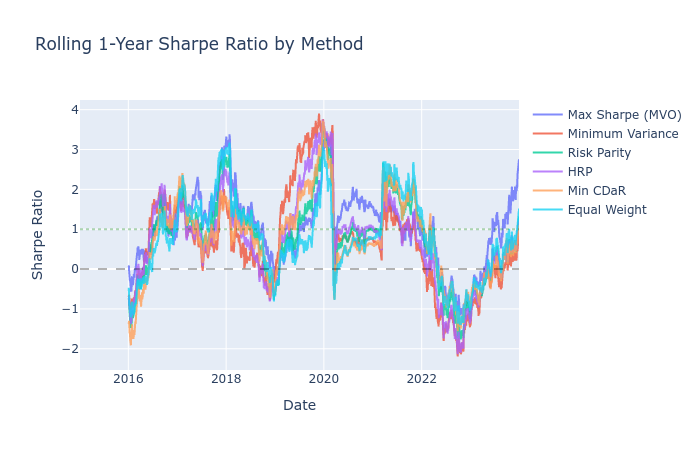

In [27]:
# Rolling 1-year Sharpe for each method
window = 252
rolling_sharpe = pd.DataFrame()

for name, ret in portfolio_returns.items():
    rolling_mean = ret.rolling(window).mean()
    rolling_std = ret.rolling(window).std()
    rolling_sharpe[name] = (rolling_mean / rolling_std) * np.sqrt(252)

# Plot
fig = go.Figure()

for col in rolling_sharpe.columns:
    fig.add_trace(go.Scatter(x=rolling_sharpe.index, y=rolling_sharpe[col], name=col, opacity=0.8))

fig.add_hline(y=0, line_dash="dash", line_color="black", opacity=0.3)
fig.add_hline(y=1, line_dash="dot", line_color="green", opacity=0.3)

fig.update_layout(
    title="Rolling 1-Year Sharpe Ratio by Method",
    xaxis_title="Date",
    yaxis_title="Sharpe Ratio",
    height=450,
)
fig.show()

## Key Takeaways

1. **Risk parity equalizes risk contributions** rather than optimizing expected returns,
   making it robust to return estimation error — the dominant source of portfolio
   construction failure.
2. **Min CDaR explicitly targets tail risk**, producing shallower drawdowns at the cost
   of lower absolute returns. This trade-off is appropriate for drawdown-sensitive mandates.
3. **Max Sharpe concentrates in few assets** (low effective N), creating fragility when
   the covariance structure shifts. Position constraints partially mitigate this.
4. **Equal weight remains competitive** across most metrics, setting a high bar for
   optimization-based methods.
5. **Ledoit-Wolf shrinkage** should be the default covariance estimator for any
   optimization that inverts or otherwise relies on the covariance matrix.

**Next**: See [`06_hierarchical_risk_parity`](06_hierarchical_risk_parity.ipynb) for a clustering-based allocation that
avoids covariance inversion entirely. [`09_allocator_comparison`](09_allocator_comparison.ipynb) compares all methods
under identical signal and execution conditions.

**Book**: §17.5 (Mean-Variance Optimization and the Markowitz Curse) covers the
Markowitz Curse and the robust fixes demonstrated here.